# The Paradox of Physical Inactivity and Happiness: A Machine Learning Approach to Global Well-being Indicators

This notebook contains the reproducible analysis pipeline for the project. It loads the source datasets, applies preprocessing, trains the statistical and machine learning models, and saves the tables and figures used for reporting.

The workflow is organized as follows:
1. Data loading, country-name harmonization, and preprocessing
2. Exploratory data analysis and figure generation
3. Linear regression models and cross-validation
4. Random Forest model training, evaluation, feature importance, and SHAP outputs
5. Gradient Boosting model training and evaluation
6. K-Means clustering and PCA visualization


In [1]:
# ==============================================================================
# ENVIRONMENT SETUP & DATA IMPORT (STANDARDIZED FOR GOOGLE COLAB & LOCAL RUNS)
# ==============================================================================
import os
import shutil

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Resolve the project root for Colab and common local launch locations
if IN_COLAB:
    PROJECT_ROOT = '.'
elif os.path.isdir(os.path.join(os.getcwd(), 'data')):
    PROJECT_ROOT = os.getcwd()
elif os.path.basename(os.getcwd()) == 'notebooks' and os.path.isdir(os.path.join('..', 'data')):
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
REPORTS_DIR = os.path.join(PROJECT_ROOT, 'reports')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')

# Create directories if they do not exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Required raw input files
REQUIRED_FILES = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']

# Check if files are uploaded in the current directory and move them to DATA_DIR
for f in REQUIRED_FILES:
    if os.path.exists(f) and not os.path.exists(os.path.join(DATA_DIR, f)):
        print(f"Moving {f} to {DATA_DIR}")
        shutil.move(f, os.path.join(DATA_DIR, f))

# Check if files are missing in DATA_DIR
missing_files = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(DATA_DIR, f))]

if missing_files and IN_COLAB:
    print(f"Missing datasets in Colab: {missing_files}")
    print("Please click 'Choose Files' to upload them directly on the page:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename in REQUIRED_FILES:
            shutil.move(filename, os.path.join(DATA_DIR, filename))
            print(f"Uploaded and moved: {filename} -> {os.path.join(DATA_DIR, filename)}")
        else:
            print(f"Warning: Unexpected file uploaded: {filename}")

# Final verification
missing_files = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing_files:
    print(f"WARNING: Required datasets are missing in {DATA_DIR}: {missing_files}")
    print("If running locally, please place the required csv files in your data/ folder.")
else:
    print("Success: All datasets are ready in the data directory!")


Missing datasets in Colab: ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
Please click 'Choose Files' to upload them directly on the page:


Saving who_physical_activity.csv to who_physical_activity.csv
Saving world_happiness_allyears.csv to world_happiness_allyears.csv
Saving world_happiness.csv to world_happiness.csv
Uploaded and moved: who_physical_activity.csv -> ./data/who_physical_activity.csv
Uploaded and moved: world_happiness_allyears.csv -> ./data/world_happiness_allyears.csv
Uploaded and moved: world_happiness.csv -> ./data/world_happiness.csv
Success: All datasets are ready in the data directory!



---
# Section 1: Data Exploration
---

# Data Exploration and Preprocessing

This section loads and harmonizes the three datasets used in the project:
- World Happiness Report 2015: happiness scores and contributing factors such as GDP, health, freedom, and social support
- World Happiness Index 2013-2023: multi-year happiness scores used to construct the long-term target variable
- WHO Physical Activity Country Profiles 2022: physical inactivity rates by age group and gender

The preprocessing workflow standardizes country names, merges the datasets, cleans numeric fields, and saves a reproducible merged dataset (`merged_clean.csv`) for the modeling sections.


## 1. Load Datasets

In [2]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make sure reports/ and models/ folders exist
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
# Load the 2015 happiness report
happiness_2015 = pd.read_csv(os.path.join(DATA_DIR, 'world_happiness.csv'))

# Load the multi-year happiness index (2013-2023)
happiness_allyears = pd.read_csv(os.path.join(DATA_DIR, 'world_happiness_allyears.csv'))

# Load WHO physical activity profiles
who = pd.read_csv(os.path.join(DATA_DIR, 'who_physical_activity.csv'))

print("Happiness 2015 shape:", happiness_2015.shape)
print("Happiness all years shape:", happiness_allyears.shape)
print("WHO shape:", who.shape)

Happiness 2015 shape: (158, 12)
Happiness all years shape: (1523, 4)
WHO shape: (194, 13)


## 2. Country Name Harmonisation

Different datasets use different country name conventions.
We standardise all three datasets to a common naming scheme before merging.
This recovers countries that were previously dropped due to name mismatches.

In [4]:
# Master mapping: non-standard name -> standard name
country_name_map = {
    # WHO typos and variants
    "Alegeria": "Algeria",
    "Austrailia": "Australia",
    "Maruitius": "Mauritius",
    "Cote D'Ivoire": "Ivory Coast",
    "Côte d'Ivoire": "Ivory Coast",
    "Lao People's Democratic Republic": "Laos",
    "Lao PDR": "Laos",
    "Democratic People's Rebulic of Korea": "North Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Republic of Korea": "South Korea",
    "Iran (Islamic Republic of)": "Iran",
    "Syrian Arab Republic": "Syria",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United States of America": "United States",
    "United Republic of Tanzania": "Tanzania",
    "Congo": "Congo (Brazzaville)",
    "Democratic Republic of the Congo": "Congo (Kinshasa)",
    "Eswatini": "Swaziland",

    # Happiness datasets
    "Congo Brazzaville": "Congo (Brazzaville)",
    "Congo Kinshasa": "Congo (Kinshasa)",
    "Czechia": "Czech Republic",
    "North Macedonia": "Macedonia",
    "Palestine": "Palestinian Territories",
    "Somaliland": "Somaliland region",
    "Turkiye": "Turkey"
}

def harmonise(df, col='Country'):
    df = df.copy()
    df[col] = df[col].str.strip().replace(country_name_map)
    return df

happiness_2015    = harmonise(happiness_2015)
happiness_allyears = harmonise(happiness_allyears)
who               = harmonise(who)

print("Harmonisation applied to all three datasets.")


Harmonisation applied to all three datasets.


## 3. Compute Average Happiness Score (2013–2023)

In [5]:
happiness_avg = happiness_allyears.groupby('Country')['Index'].mean().reset_index()
happiness_avg.columns = ['Country', 'Happiness Score Avg']

print("Countries with avg score:", len(happiness_avg))
print(happiness_avg.head(5))

Countries with avg score: 165
       Country  Happiness Score Avg
0  Afghanistan               3.0957
1      Albania               4.9589
2      Algeria               5.4103
3       Angola               4.2156
4    Argentina               6.2754


## 4. Merge Datasets

The three datasets are joined on standardized country names. The final merged dataset contains 152 countries and 27 features after harmonization.

The supervised models use the 2013-2023 average happiness index (`Happiness Score Avg`) as the target variable. The predictor set includes adult physical inactivity and the selected socio-economic variables used in the report.


In [6]:
df = pd.merge(happiness_2015, happiness_avg, on='Country', how='inner')
df = pd.merge(df, who, on='Country', how='inner')

print("Final merged shape:", df.shape)
print("Countries in final dataset:", df['Country'].nunique())
print()
print("Columns:", df.columns.tolist())

Final merged shape: (152, 25)
Countries in final dataset: 152

Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Happiness Score Avg', 'Total Population (2022)', 'Population Aged < 20 (%)', 'Population Aged > 60 (%)', 'Deaths Due to NCD', 'World Bank Income Group', 'GDP per capita (INT$)', 'Physical Inactivity, Adolescents Aged 11-17 (%), Male', 'Physical Inactivity, Adolescents Aged 11-17 (%), Female', 'Physical Inactivity, Adults Aged 18+ (%), Male', 'Physical Inactivity, Adults Aged 18+ (%), Female', 'Physical Inactivity, Adults Aged 70+ (%), Male', 'Physical Inactivity, Adults Aged 70+ (%), Female']


In [7]:
# Show which WHO countries still didn't match — helps spot remaining mismatches
merged_countries = set(df['Country'])
who_countries    = set(who['Country'])
unmatched = who_countries - merged_countries
print(f"{len(unmatched)} WHO countries still unmatched:")
for c in sorted(unmatched):
    print(" -", c)

42 WHO countries still unmatched:
 - Andorra
 - Antigua and Barbuda
 - Bahamas
 - Barbados
 - Belize
 - Brunei Darussalam
 - Cabo Verde
 - Cook Islands
 - Cuba
 - Dominica
 - Equatorial Guinea
 - Eritrea
 - Fiji
 - Gambia
 - Grenada
 - Guinea-Bissau
 - Guyana
 - Kiribati
 - Maldives
 - Marshall Islands
 - Micronesia (Federated States of)
 - Monaco
 - Namibia
 - Nauru
 - Niue
 - North Korea
 - Palau
 - Papua New Guinea
 - Saint Kitts and Nevis
 - Saint Lucia
 - Saint Vincent and the Grenadines
 - Samoa
 - San Marino
 - Sao Tome and Principe
 - Seychelles
 - Solomon Islands
 - Somalia
 - South Sudan
 - Timor-Leste
 - Tonga
 - Tuvalu
 - Vanuatu


## 5. Data Cleaning

- Strip `%` from WHO inactivity columns and convert to float
- Fill missing values with column mean
- Create summary columns: `Avg Inactivity Adults` and `Avg Inactivity Adolescents`
- Fix population and percentage columns

In [8]:
who_cols = [
    'Physical Inactivity, Adolescents Aged 11-17 (%), Male',
    'Physical Inactivity, Adolescents Aged 11-17 (%), Female',
    'Physical Inactivity, Adults Aged 18+ (%), Male',
    'Physical Inactivity, Adults Aged 18+ (%), Female',
    'Physical Inactivity, Adults Aged 70+ (%), Male',
    'Physical Inactivity, Adults Aged 70+ (%), Female'
]

for col in who_cols:
    df[col] = df[col].astype(str).str.replace('%', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[who_cols] = df[who_cols].fillna(df[who_cols].mean())

df['Avg Inactivity Adults'] = df[[
    'Physical Inactivity, Adults Aged 18+ (%), Male',
    'Physical Inactivity, Adults Aged 18+ (%), Female'
]].mean(axis=1)

df['Avg Inactivity Adolescents'] = df[[
    'Physical Inactivity, Adolescents Aged 11-17 (%), Male',
    'Physical Inactivity, Adolescents Aged 11-17 (%), Female'
]].mean(axis=1)

# Fix population and percentage columns
df['Total Population (2022)'] = pd.to_numeric(
    df['Total Population (2022)'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

for col in ['Population Aged < 20 (%)', 'Population Aged > 60 (%)', 'Deaths Due to NCD']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('%', '').str.strip(),
        errors='coerce'
    )

df['GDP per capita (INT$)'] = df['GDP per capita (INT$)'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
df['GDP per capita (INT$)'] = pd.to_numeric(df['GDP per capita (INT$)'], errors='coerce')
df['GDP per capita (INT$)'] = df['GDP per capita (INT$)'].fillna(df['GDP per capita (INT$)'].mean())

print("Missing values after cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "None — dataset is clean!")
print()
print(df[['Country', 'Happiness Score', 'Avg Inactivity Adults']].head(5))

Missing values after cleaning:
None — dataset is clean!

       Country  Happiness Score  Avg Inactivity Adults
0  Switzerland            7.587              24.000000
1      Iceland            7.561              28.561538
2      Denmark            7.527              28.500000
3       Norway            7.522              32.000000
4       Canada            7.427              28.500000


## 6. Outlier Detection

The IQR method is used to flag potential outliers in selected numerical columns. The flagged rows are printed for inspection; they are not removed in this pipeline.


In [9]:
key_cols = ['Happiness Score', 'Avg Inactivity Adults', 'Economy (GDP per Capita)',
            'Health (Life Expectancy)', 'Freedom']

print("=== Outlier Report (IQR method) ===")
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]['Country'].tolist()
    print(f"  {col}: {len(outliers)} outlier(s) — {outliers}")

=== Outlier Report (IQR method) ===
  Happiness Score: 0 outlier(s) — []
  Avg Inactivity Adults: 2 outlier(s) — ['Saudi Arabia', 'Kuwait']
  Economy (GDP per Capita): 0 outlier(s) — []
  Health (Life Expectancy): 0 outlier(s) — []
  Freedom: 0 outlier(s) — []


## 7. Save Clean Dataset

In [10]:
df.to_csv(os.path.join(DATA_DIR, 'merged_clean.csv'), index=False)
print("Saved merged_clean.csv — Shape:", df.shape)

Saved merged_clean.csv — Shape: (152, 27)



---
# Section 2: EDA
---

# Exploratory Data Analysis

This section generates descriptive tables and figures from the cleaned dataset. All figures are saved to the `reports/` folder.

Contents:
1. Load cleaned dataset
2. Scatter plot: Physical Inactivity vs Happiness
3. Correlation matrix
4. Happiness score by region
5. Top 10 happiest and least happy countries
6. Physical inactivity by region
7. Gender gap in physical inactivity
8. Happiness and inactivity by income group


In [11]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs(REPORTS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, 'merged_clean.csv'))
print("Dataset shape:", df.shape)
print("Regions:", df['Region'].nunique())
df.head()

Dataset shape: (152, 27)
Regions: 10


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,World Bank Income Group,GDP per capita (INT$),"Physical Inactivity, Adolescents Aged 11-17 (%), Male","Physical Inactivity, Adolescents Aged 11-17 (%), Female","Physical Inactivity, Adults Aged 18+ (%), Male","Physical Inactivity, Adults Aged 18+ (%), Female","Physical Inactivity, Adults Aged 70+ (%), Male","Physical Inactivity, Adults Aged 70+ (%), Female",Avg Inactivity Adults,Avg Inactivity Adolescents
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,HIGH,71745.0,83.0,89.0,22.0,26.000000,34.000000,41.000000,24.000000,86.0
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,HIGH,53617.0,75.0,85.0,24.7,32.423077,35.407692,44.992308,28.561538,80.0
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,HIGH,60230.0,82.0,87.0,26.0,31.000000,39.000000,46.000000,28.500000,84.5
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,HIGH,62645.0,79.0,89.0,30.0,34.000000,44.000000,50.000000,32.000000,84.0
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,HIGH,46572.0,71.0,82.0,26.0,31.000000,39.000000,47.000000,28.500000,76.5


## 2. Scatter Plot: Physical Inactivity vs Happiness

Final report: Fig. 3 (`reports/inactivity_vs_happiness.png`).


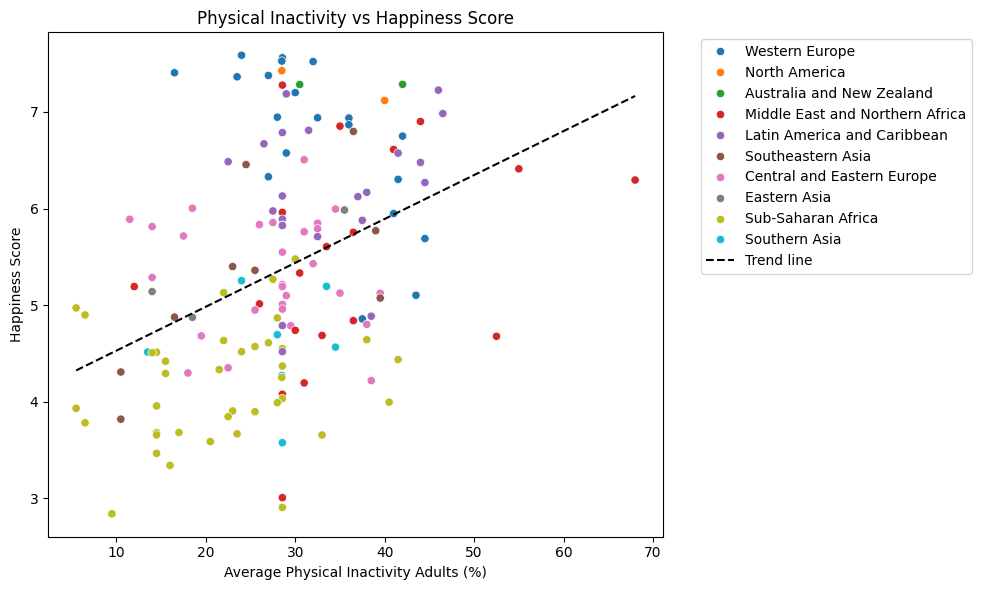

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Avg Inactivity Adults', y='Happiness Score', hue='Region')

# Add regression line
m, b = np.polyfit(df['Avg Inactivity Adults'], df['Happiness Score'], 1)
x_line = np.linspace(df['Avg Inactivity Adults'].min(), df['Avg Inactivity Adults'].max(), 100)
plt.plot(x_line, m*x_line + b, color='black', linestyle='--', linewidth=1.5, label='Trend line')

plt.title('Physical Inactivity vs Happiness Score')
plt.xlabel('Average Physical Inactivity Adults (%)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'inactivity_vs_happiness.png'), dpi=150)
plt.show()

## 3. Correlation Matrix

Final report: Fig. 1 (`reports/correlation_matrix.png`).


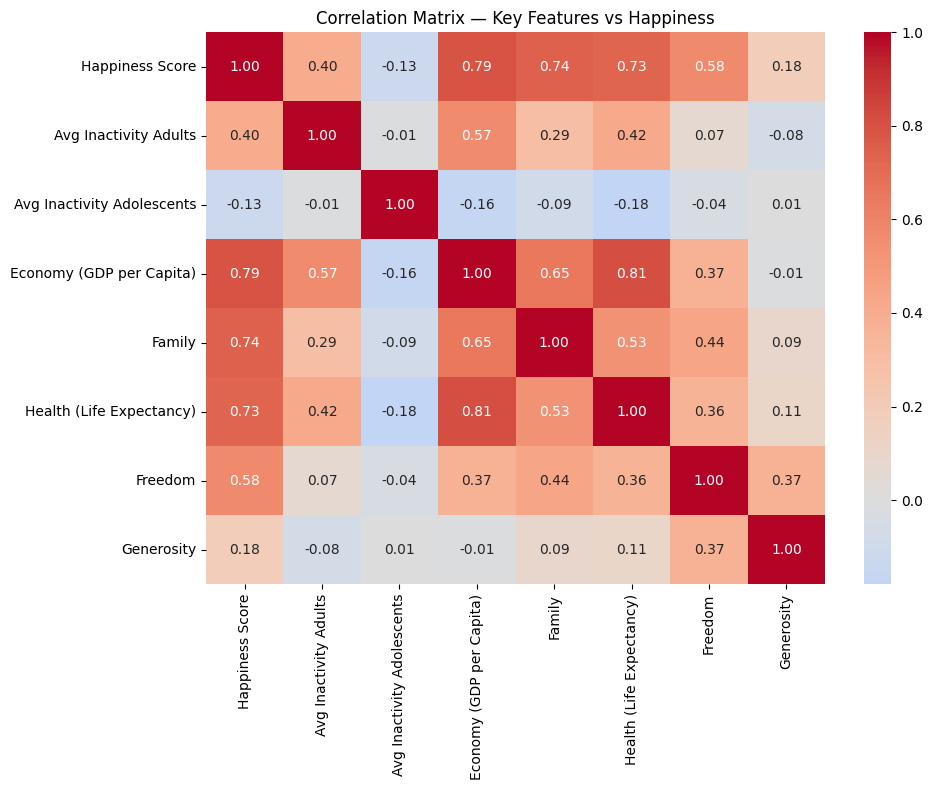


Correlation with Happiness Score:
Happiness Score               1.000000
Economy (GDP per Capita)      0.788295
Family                        0.742571
Health (Life Expectancy)      0.730712
Freedom                       0.575680
Avg Inactivity Adults         0.397475
Generosity                    0.183141
Avg Inactivity Adolescents   -0.128454


In [13]:
corr_cols = [
    'Happiness Score',
    'Avg Inactivity Adults',
    'Avg Inactivity Adolescents',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Generosity'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Key Features vs Happiness')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'correlation_matrix.png'), dpi=150)
plt.show()

print("\nCorrelation with Happiness Score:")
print(corr['Happiness Score'].sort_values(ascending=False).to_string())

## 4. Happiness Score by Region


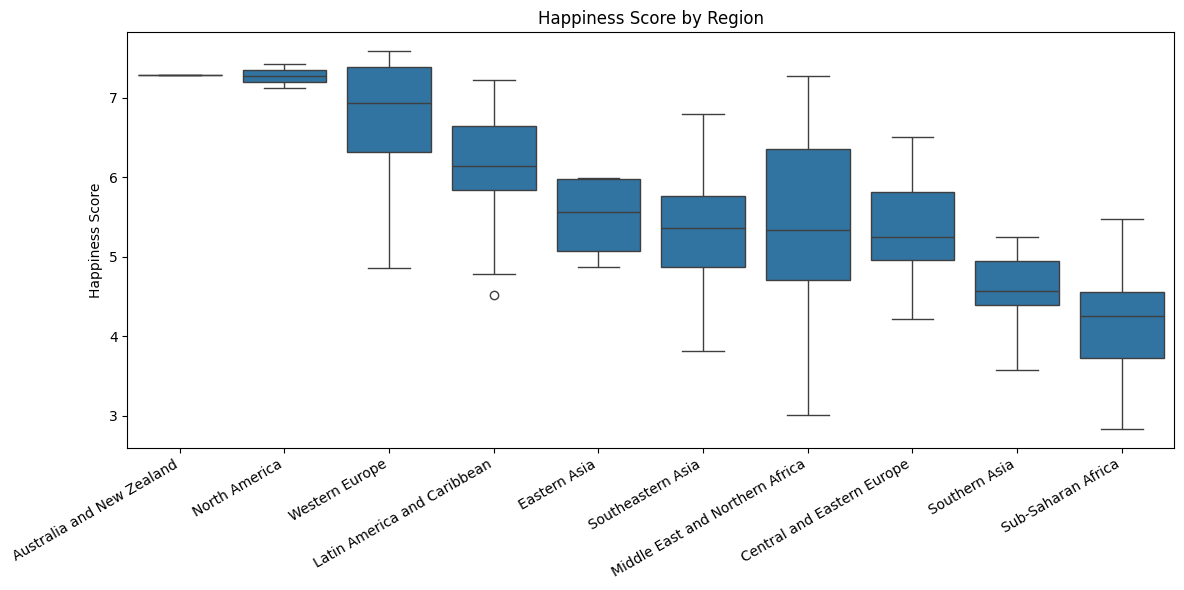

In [14]:
region_order = df.groupby('Region')['Happiness Score'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Happiness Score', order=region_order)
plt.title('Happiness Score by Region')
plt.xlabel('')
plt.ylabel('Happiness Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'happiness_by_region.png'), dpi=150)
plt.show()

## 5. Top 10 Happiest and Least Happy Countries


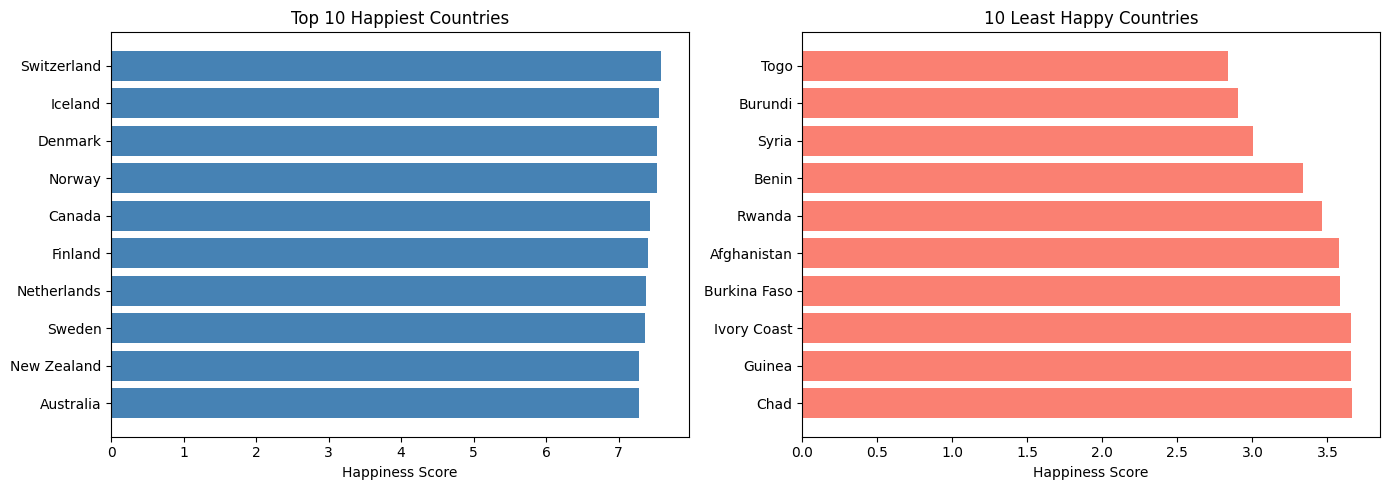

Top 10:
    Country  Happiness Score  Avg Inactivity Adults
Switzerland            7.587              24.000000
    Iceland            7.561              28.561538
    Denmark            7.527              28.500000
     Norway            7.522              32.000000
     Canada            7.427              28.500000
    Finland            7.406              16.500000
Netherlands            7.378              27.000000
     Sweden            7.364              23.500000
New Zealand            7.286              42.000000
  Australia            7.284              30.500000

Bottom 10:
     Country  Happiness Score  Avg Inactivity Adults
        Togo            2.839               9.500000
     Burundi            2.905              28.561538
       Syria            3.006              28.561538
       Benin            3.340              16.000000
      Rwanda            3.465              14.500000
 Afghanistan            3.575              28.561538
Burkina Faso            3.587        

In [15]:
top10 = df.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score', 'Avg Inactivity Adults']]
bottom10 = df.nsmallest(10, 'Happiness Score')[['Country', 'Happiness Score', 'Avg Inactivity Adults']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10['Country'], top10['Happiness Score'], color='steelblue')
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Happiness Score')
axes[0].invert_yaxis()

axes[1].barh(bottom10['Country'], bottom10['Happiness Score'], color='salmon')
axes[1].set_title('10 Least Happy Countries')
axes[1].set_xlabel('Happiness Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'top_bottom_countries.png'), dpi=150)
plt.show()

print("Top 10:")
print(top10.to_string(index=False))
print("\nBottom 10:")
print(bottom10.to_string(index=False))

## 6. Physical Inactivity by Region


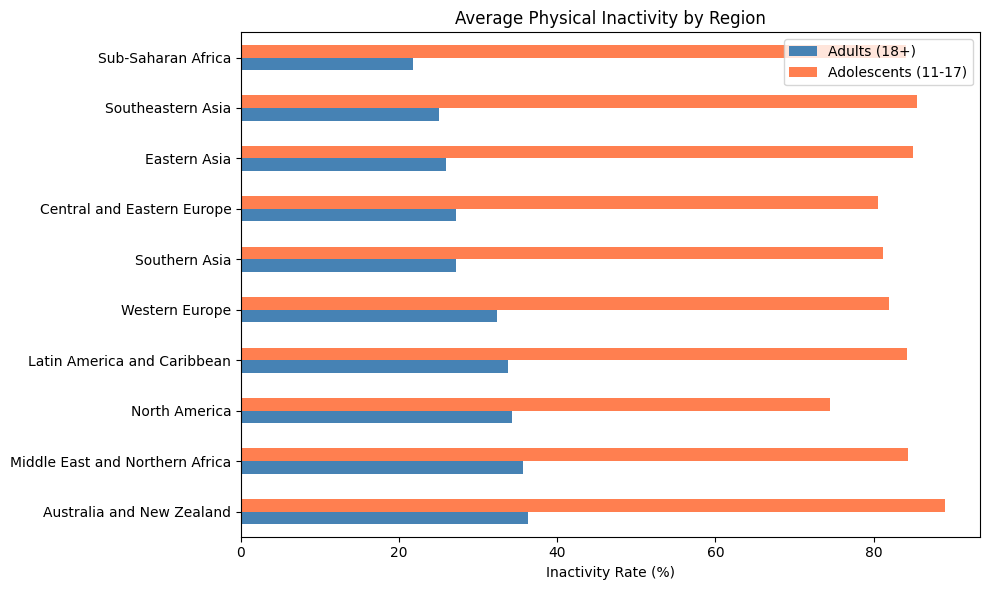

In [16]:
inactivity_region = df.groupby('Region')[['Avg Inactivity Adults', 'Avg Inactivity Adolescents']].mean()
inactivity_region = inactivity_region.sort_values('Avg Inactivity Adults', ascending=False)

inactivity_region.plot(kind='barh', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Average Physical Inactivity by Region')
plt.xlabel('Inactivity Rate (%)')
plt.ylabel('')
plt.legend(['Adults (18+)', 'Adolescents (11-17)'])
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'inactivity_by_region.png'), dpi=150)
plt.show()

## 7. Gender Gap in Physical Inactivity


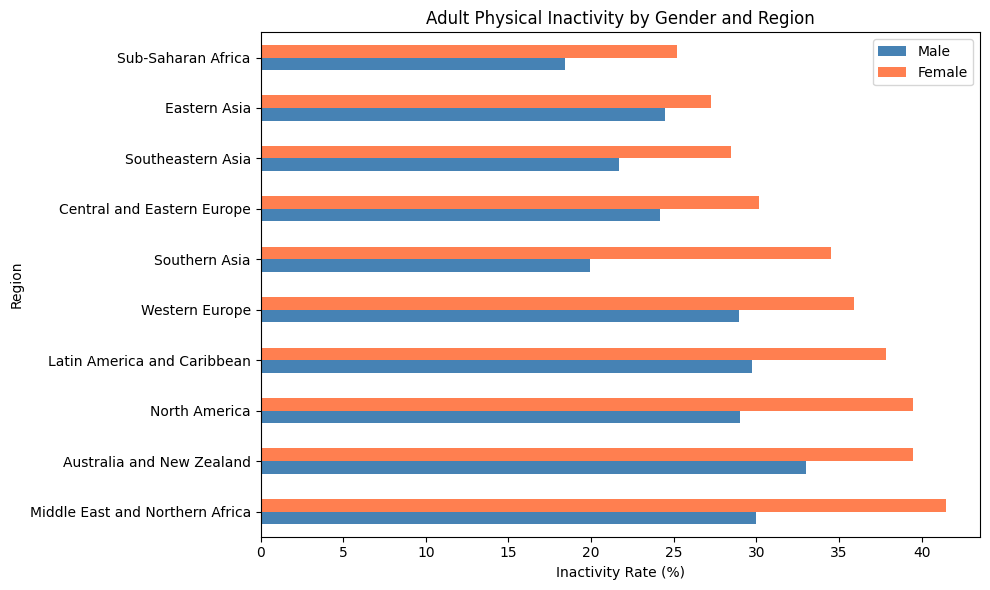

Average gender gap (Female - Male) per region:
Region
Southern Asia                      14.53
Middle East and Northern Africa    11.47
North America                      10.50
Latin America and Caribbean         8.09
Western Europe                      6.99
Southeastern Asia                   6.78
Sub-Saharan Africa                  6.74
Australia and New Zealand           6.50
Central and Eastern Europe          5.99
Eastern Asia                        2.75


In [17]:
df['Gender Gap Adults'] = (
    df['Physical Inactivity, Adults Aged 18+ (%), Female'] -
    df['Physical Inactivity, Adults Aged 18+ (%), Male']
)

gender_region = df.groupby('Region')[[
    'Physical Inactivity, Adults Aged 18+ (%), Male',
    'Physical Inactivity, Adults Aged 18+ (%), Female'
]].mean().sort_values('Physical Inactivity, Adults Aged 18+ (%), Female', ascending=False)

gender_region.columns = ['Male', 'Female']
gender_region.plot(kind='barh', figsize=(10, 6), color=['steelblue', 'coral'])
plt.title('Adult Physical Inactivity by Gender and Region')
plt.xlabel('Inactivity Rate (%)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'gender_gap_inactivity.png'), dpi=150)
plt.show()

print("Average gender gap (Female - Male) per region:")
print(df.groupby('Region')['Gender Gap Adults'].mean().sort_values(ascending=False).round(2).to_string())

## 8. Happiness and Inactivity by Income Group


Countries by income group:
Income Group
Low income             25
Lower middle income    38
Upper middle income    42
High income            47


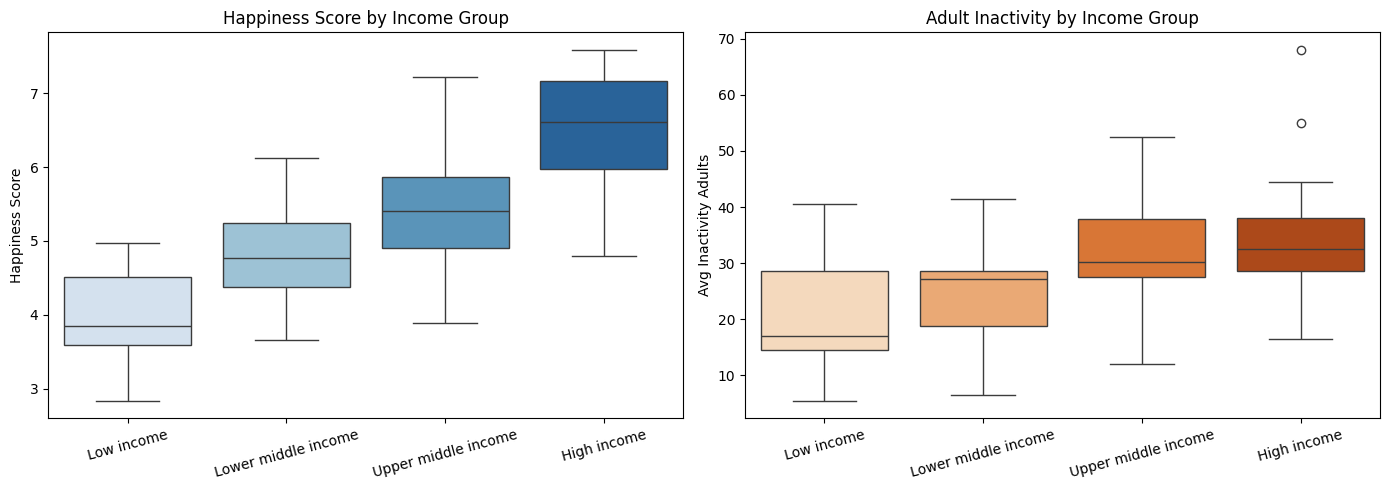

In [18]:
if 'World Bank Income Group' in df.columns:
    income_label_map = {
        'LOW': 'Low income',
        'LOWER MIDDLE': 'Lower middle income',
        'UPPER MIDDLE': 'Upper middle income',
        'HIGH': 'High income'
    }
    income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
    income_data = df.copy()
    income_data['Income Group'] = (
        income_data['World Bank Income Group']
        .astype(str)
        .str.strip()
        .str.upper()
        .map(income_label_map)
    )
    income_data = income_data[income_data['Income Group'].isin(income_order)]
    print('Countries by income group:')
    print(income_data['Income Group'].value_counts().reindex(income_order).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=income_data, x='Income Group', y='Happiness Score', hue='Income Group',
                order=income_order, hue_order=income_order, ax=axes[0], palette='Blues', legend=False)
    axes[0].set_title('Happiness Score by Income Group')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=15)

    sns.boxplot(data=income_data, x='Income Group', y='Avg Inactivity Adults', hue='Income Group',
                order=income_order, hue_order=income_order, ax=axes[1], palette='Oranges', legend=False)
    axes[1].set_title('Adult Inactivity by Income Group')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'income_group_analysis.png'), dpi=150)
    plt.show()
else:
    print("World Bank Income Group column not found — skipping.")


---
# Section 3: Linear Regression
---

# Linear Regression: Happiness Score Models

This section trains two Linear Regression models:
1. Simple model: `Avg Inactivity Adults` as the only predictor
2. Multiple model: adult inactivity plus GDP, health, family, and freedom predictors

The cells below print coefficients, error metrics, adjusted R², and 5-fold cross-validation scores.


In [19]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


def get_adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

df = pd.read_csv(os.path.join(DATA_DIR, 'merged_clean.csv'))
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (152, 27)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,World Bank Income Group,GDP per capita (INT$),"Physical Inactivity, Adolescents Aged 11-17 (%), Male","Physical Inactivity, Adolescents Aged 11-17 (%), Female","Physical Inactivity, Adults Aged 18+ (%), Male","Physical Inactivity, Adults Aged 18+ (%), Female","Physical Inactivity, Adults Aged 70+ (%), Male","Physical Inactivity, Adults Aged 70+ (%), Female",Avg Inactivity Adults,Avg Inactivity Adolescents
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,HIGH,71745.0,83.0,89.0,22.0,26.000000,34.000000,41.000000,24.000000,86.0
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,HIGH,53617.0,75.0,85.0,24.7,32.423077,35.407692,44.992308,28.561538,80.0
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,HIGH,60230.0,82.0,87.0,26.0,31.000000,39.000000,46.000000,28.500000,84.5
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,HIGH,62645.0,79.0,89.0,30.0,34.000000,44.000000,50.000000,32.000000,84.0
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,HIGH,46572.0,71.0,82.0,26.0,31.000000,39.000000,47.000000,28.500000,76.5


## 1. Feature Selection

In [20]:
TARGET = 'Happiness Score Avg'

SIMPLE_FEATURES = ['Avg Inactivity Adults']

MULTI_FEATURES = [
    'Avg Inactivity Adults',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom'
]

# Drop rows with any missing values in our feature/target columns
df_model = df[MULTI_FEATURES + [TARGET, 'Country']].dropna()
print(f"Rows used for modelling: {len(df_model)} (dropped {len(df) - len(df_model)})")

Rows used for modelling: 152 (dropped 0)


## 2. Train / Test Split

In [21]:
X_multi = df_model[MULTI_FEATURES]
X_simple = df_model[SIMPLE_FEATURES]
y = df_model[TARGET]

X_train_m, X_test_m, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)
X_train_s = X_train_m[SIMPLE_FEATURES]
X_test_s  = X_test_m[SIMPLE_FEATURES]

print(f"Train: {len(X_train_m)} | Test: {len(X_test_m)}")

Train: 121 | Test: 31


## 3. Simple Linear Regression (Inactivity only)

The simple model estimates the bivariate association between adult physical inactivity and long-term average happiness. It provides the baseline relationship that is later compared with the multiple OLS model including socio-economic covariates.


In [22]:
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train)

y_pred_simple = lr_simple.predict(X_test_s)

r2_simple  = r2_score(y_test, y_pred_simple)
adj_r2_simple = get_adjusted_r2(r2_simple, len(y_test), X_train_s.shape[1])
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("=== Simple Linear Regression ===")
print(f"  R²   : {r2_simple:.4f}")
print(f"  Adjusted R²: {adj_r2_simple:.4f}")
print(f"  MAE  : {mae_simple:.4f}")
print(f"  RMSE : {rmse_simple:.4f}")
print(f"  Coefficient (Inactivity): {lr_simple.coef_[0]:.4f}")
print(f"  Intercept               : {lr_simple.intercept_:.4f}")

=== Simple Linear Regression ===
  R²   : 0.3093
  Adjusted R²: 0.2855
  MAE  : 0.7546
  RMSE : 0.9123
  Coefficient (Inactivity): 0.0406
  Intercept               : 4.2583


## 4. Multiple Linear Regression (All features)

In [23]:
lr_multi = LinearRegression()
lr_multi.fit(X_train_m, y_train)

y_pred_multi = lr_multi.predict(X_test_m)

r2_multi  = r2_score(y_test, y_pred_multi)
adj_r2_multi = get_adjusted_r2(r2_multi, len(y_test), X_train_m.shape[1])
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression ===")
print(f"  R²   : {r2_multi:.4f}")
print(f"  Adjusted R²: {adj_r2_multi:.4f}")
print(f"  MAE  : {mae_multi:.4f}")
print(f"  RMSE : {rmse_multi:.4f}")
print()
print("Feature coefficients:")
for feat, coef in zip(MULTI_FEATURES, lr_multi.coef_):
    print(f"  {feat:<45} {coef:+.4f}")

=== Multiple Linear Regression ===
  R²   : 0.8292
  Adjusted R²: 0.7950
  MAE  : 0.3431
  RMSE : 0.4537

Feature coefficients:
  Avg Inactivity Adults                         +0.0017
  Economy (GDP per Capita)                      +0.5647
  Family                                        +1.1339
  Health (Life Expectancy)                      +1.4563
  Freedom                                       +2.0356


## 4.5 Multicollinearity (VIF) Analysis

Multiple linear regression assumes features are not highly correlated.
We calculate the **Variance Inflation Factor (VIF)** to check for multicollinearity.

In [24]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant column for OLS intercept VIF calculation
X_vif = sm.add_constant(X_multi)

vif_data = pd.DataFrame()
vif_data["feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(X_multi.shape[1])]

print("=== Variance Inflation Factors (VIF) ===")
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))


=== Variance Inflation Factors (VIF) ===
                 feature      VIF
Economy (GDP per Capita) 4.568923
Health (Life Expectancy) 3.017585
                  Family 1.903954
   Avg Inactivity Adults 1.539274
                 Freedom 1.303177


## 5. Cross-Validation (5-fold)

In [25]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_simple = cross_val_score(LinearRegression(), X_simple, y, cv=kf, scoring='r2')
cv_multi  = cross_val_score(LinearRegression(), X_multi,  y, cv=kf, scoring='r2')

print("5-Fold CV R² (Shuffled) — Simple : ", cv_simple.round(3), f"→ mean {cv_simple.mean():.3f}")
print("5-Fold CV R² (Shuffled) — Multiple:", cv_multi.round(3),  f"→ mean {cv_multi.mean():.3f}")


5-Fold CV R² (Shuffled) — Simple :  [ 0.309  0.109 -0.175  0.218  0.201] → mean 0.133
5-Fold CV R² (Shuffled) — Multiple: [0.829 0.784 0.779 0.857 0.787] → mean 0.807


## 6. Visualisations

Final report: Fig. 9 (`reports/lr_simple_regression.png`) and Fig. 11 (`reports/lr_multiple_actual_vs_predicted.png`).


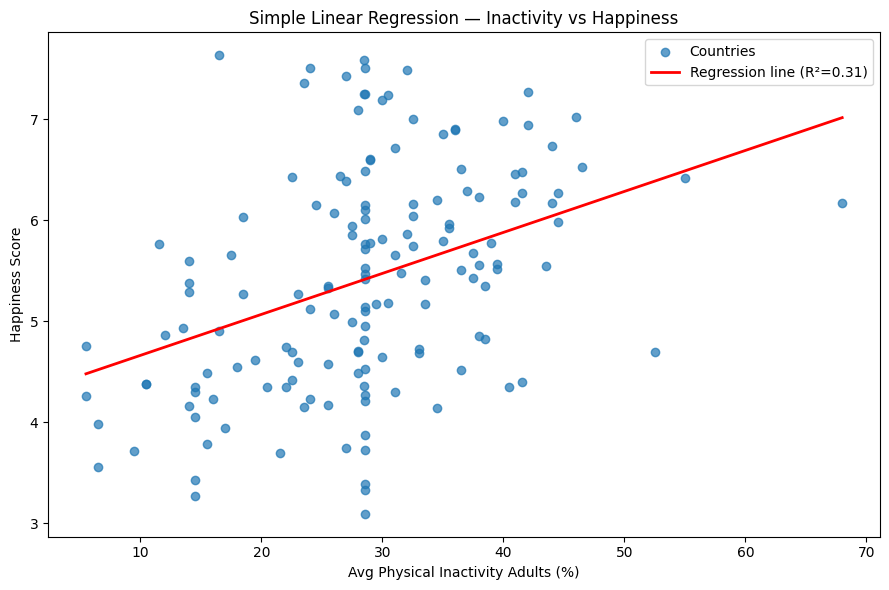

In [26]:
# Simple regression line on scatter plot
x_range = np.linspace(df_model['Avg Inactivity Adults'].min(),
                      df_model['Avg Inactivity Adults'].max(), 100).reshape(-1, 1)
x_range_df = pd.DataFrame(x_range, columns=['Avg Inactivity Adults'])
y_line = lr_simple.predict(x_range_df)

plt.figure(figsize=(9, 6))
plt.scatter(df_model['Avg Inactivity Adults'], y, alpha=0.7, label='Countries')
plt.plot(x_range, y_line, color='red', linewidth=2,
         label=f'Regression line (R²={r2_simple:.2f})')
plt.xlabel('Avg Physical Inactivity Adults (%)')
plt.ylabel('Happiness Score')
plt.title('Simple Linear Regression — Inactivity vs Happiness')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'lr_simple_regression.png'), dpi=150)
plt.show()

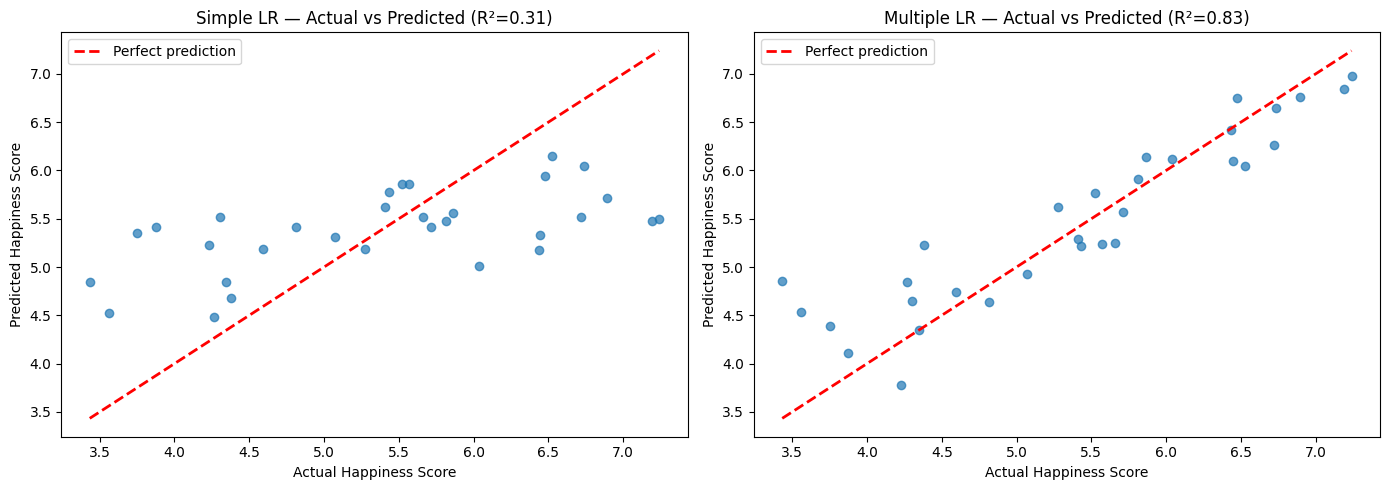

In [27]:
# Actual vs Predicted — Multiple model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, r2 in [
    (axes[0], y_pred_simple, 'Simple LR', r2_simple),
    (axes[1], y_pred_multi,  'Multiple LR', r2_multi)
]:
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual Happiness Score')
    ax.set_ylabel('Predicted Happiness Score')
    ax.set_title(f'{title} — Actual vs Predicted (R²={r2:.2f})')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'lr_actual_vs_predicted.png'), dpi=150)
plt.show()

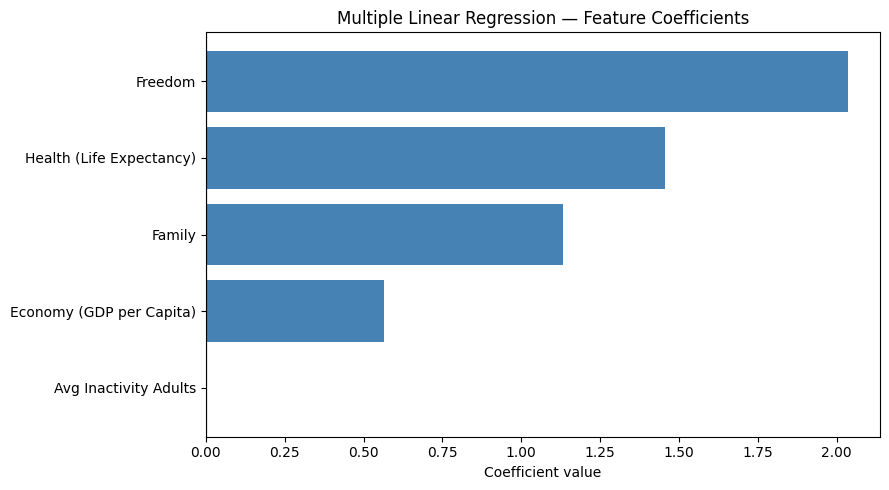

In [28]:
# Coefficient plot for multiple regression
coef_df = pd.DataFrame({'Feature': MULTI_FEATURES, 'Coefficient': lr_multi.coef_})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(9, 5))
colors = ['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Multiple Linear Regression — Feature Coefficients')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'lr_coefficients.png'), dpi=150)
plt.show()

## 7. Summary Table

In [29]:
summary = pd.DataFrame({
    'Model': ['Simple LR (inactivity only)', 'Multiple LR (all features)'],
    'R²':   [round(r2_simple, 4),  round(r2_multi, 4)],
    'Adjusted R²': [round(adj_r2_simple, 4), round(adj_r2_multi, 4)],
    'MAE':  [round(mae_simple, 4), round(mae_multi, 4)],
    'RMSE': [round(rmse_simple, 4), round(rmse_multi, 4)]
})
print(summary.to_string(index=False))

                      Model     R²  Adjusted R²    MAE   RMSE
Simple LR (inactivity only) 0.3093       0.2855 0.7546 0.9123
 Multiple LR (all features) 0.8292       0.7950 0.3431 0.4537


## 7.5 Epidemiological Sub-Model: Predicting Deaths due to NCD

We analyze the direct health impact of physical inactivity by predicting **Deaths Due to NCD** (Non-Communicable Diseases, e.g., cardiovascular disease, diabetes) using adult inactivity rates, raw GDP, and population aging.

NCD Model rows: 152
=== NCD Model Performance ===
  R²   : 0.6612
  Adjusted R²: 0.6236
  MAE  : 9.7332
  RMSE : 11.7759
  CV R² (5-fold, Shuffled): [0.661 0.594 0.537 0.636 0.681] → mean 0.622

Feature Coefficients:
  Avg Inactivity Adults         : +0.251964
  GDP per capita (INT$)         : +0.000095
  Population Aged > 60 (%)      : +1.625921
  Intercept                     : 39.2181


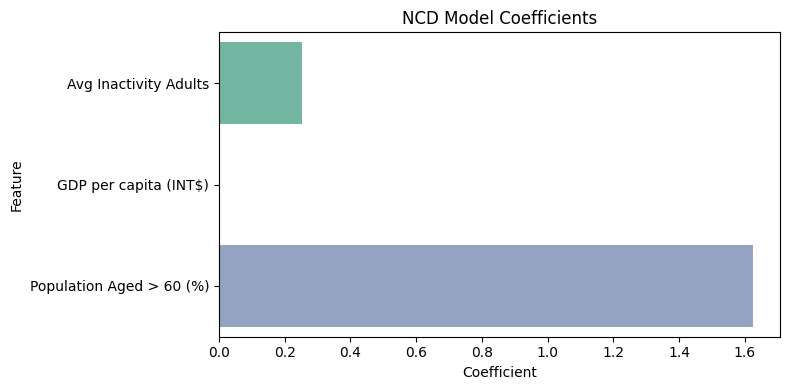

In [30]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

# Predict Deaths Due to NCD
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

NCD_TARGET = 'Deaths Due to NCD'
NCD_FEATURES = ['Avg Inactivity Adults', 'GDP per capita (INT$)', 'Population Aged > 60 (%)']

df_ncd = df[['Country'] + NCD_FEATURES + [NCD_TARGET]].dropna()
print(f"NCD Model rows: {len(df_ncd)}")

X_ncd = df_ncd[NCD_FEATURES]
y_ncd = df_ncd[NCD_TARGET]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_ncd, y_ncd, test_size=0.2, random_state=42)

lr_ncd = LinearRegression()
lr_ncd.fit(X_train_n, y_train_n)
y_pred_ncd = lr_ncd.predict(X_test_n)

r2_ncd = r2_score(y_test_n, y_pred_ncd)
adj_r2_ncd = get_adjusted_r2(r2_ncd, len(y_test_n), X_train_n.shape[1])
mae_ncd = mean_absolute_error(y_test_n, y_pred_ncd)
rmse_ncd = np.sqrt(mean_squared_error(y_test_n, y_pred_ncd))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_ncd = cross_val_score(LinearRegression(), X_ncd, y_ncd, cv=kf, scoring='r2')

print("=== NCD Model Performance ===")
print(f"  R²   : {r2_ncd:.4f}")
print(f"  Adjusted R²: {adj_r2_ncd:.4f}")
print(f"  MAE  : {mae_ncd:.4f}")
print(f"  RMSE : {rmse_ncd:.4f}")
print(f"  CV R² (5-fold, Shuffled): {cv_ncd.round(3)} → mean {cv_ncd.mean():.3f}")

print("\nFeature Coefficients:")
for feat, coef in zip(NCD_FEATURES, lr_ncd.coef_):
    print(f"  {feat:30s}: {coef:+.6f}")
print(f"  Intercept                     : {lr_ncd.intercept_:.4f}")

# Plot coefficients
plt.figure(figsize=(8, 4))
coef_df = pd.DataFrame({'Feature': NCD_FEATURES, 'Coefficient': lr_ncd.coef_})
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='Set2', legend=False)
plt.title('NCD Model Coefficients')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'ncd_coefficients.png'), dpi=150)
plt.show()

# Save NCD model
with open(os.path.join(MODELS_DIR, 'lr_ncd.pkl'), 'wb') as f:
    pickle.dump(lr_ncd, f)


## 8. Save Models

In [31]:
with open(os.path.join(MODELS_DIR, 'lr_simple.pkl'), 'wb') as f:
    pickle.dump(lr_simple, f)

with open(os.path.join(MODELS_DIR, 'lr_multi.pkl'), 'wb') as f:
    pickle.dump(lr_multi, f)

print("Models saved to models/")

Models saved to models/



---
# Section 4: Random Forest
---

# Random Forest Regression

This section trains a Random Forest regressor using the same target and feature set as the multiple linear model. It prints test metrics, cross-validation metrics, feature importance, SHAP outputs, and prediction plots.


In [32]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, 'merged_clean.csv'))
print("Dataset shape:", df.shape)

Dataset shape: (152, 27)


## 1. Feature Selection & Split

In [33]:
TARGET = 'Happiness Score Avg'

FEATURES = [
    'Avg Inactivity Adults',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom'
]

df_model = df[FEATURES + [TARGET, 'Country']].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 121 | Test: 31


## 2. Baseline Random Forest

In [34]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

r2_base   = r2_score(y_test, y_pred_base)
mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print("=== Baseline Random Forest ===")
print(f"  R²   : {r2_base:.4f}")
print(f"  MAE  : {mae_base:.4f}")
print(f"  RMSE : {rmse_base:.4f}")

=== Baseline Random Forest ===
  R²   : 0.8821
  MAE  : 0.3026
  RMSE : 0.3770


## 3. Hyperparameter Tuning (GridSearchCV)

GridSearchCV is used to select Random Forest hyperparameters on the training split. The selected estimator is evaluated on the held-out test set and with shuffled 5-fold cross-validation.


In [35]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:      ", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV R²:       0.8141


## 4. Best Model Evaluation

In [36]:
from sklearn.model_selection import KFold

rf_best = grid_search.best_estimator_
y_pred_best = rf_best.predict(X_test)

r2_best   = r2_score(y_test, y_pred_best)
mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

# Cross-validation on tuned model using shuffled KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_best, X, y, cv=kf, scoring='r2')

print("=== Tuned Random Forest ===")
print(f"  R²   : {r2_best:.4f}")
print(f"  MAE  : {mae_best:.4f}")
print(f"  RMSE : {rmse_best:.4f}")
print(f"  CV R² (5-fold, Shuffled): {cv_scores.round(3)} → mean {cv_scores.mean():.3f}")

rf_r2_best = r2_best
rf_mae_best = mae_best
rf_rmse_best = rmse_best
rf_cv_scores = cv_scores.copy()


=== Tuned Random Forest ===
  R²   : 0.8763
  MAE  : 0.3053
  RMSE : 0.3861
  CV R² (5-fold, Shuffled): [0.872 0.792 0.812 0.844 0.795] → mean 0.823


## 5. Feature Importance

Final report: Fig. 13 (`reports/rf_feature_importance.png`).


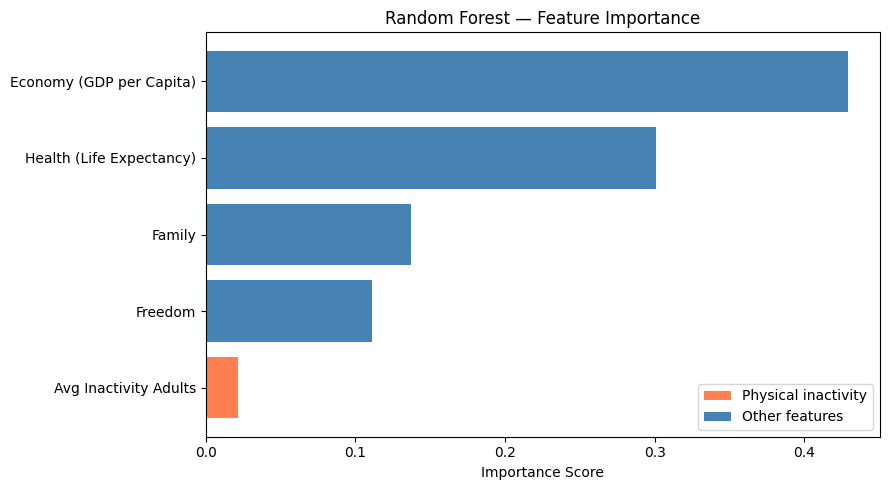


Feature Importance (sorted):
                 Feature  Importance
Economy (GDP per Capita)    0.429154
Health (Life Expectancy)    0.301144
                  Family    0.137079
                 Freedom    0.111038
   Avg Inactivity Adults    0.021584


In [37]:
importances = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['coral' if 'Inactivity' in f else 'steelblue' for f in importances['Feature']]
plt.barh(importances['Feature'], importances['Importance'], color=colors)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Physical inactivity'),
                   Patch(facecolor='steelblue', label='Other features')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'rf_feature_importance.png'), dpi=150)
plt.show()

print("\nFeature Importance (sorted):")
print(importances.sort_values('Importance', ascending=False).to_string(index=False))

## 5.5 Explaining Predictions with SHAP (SHapley Additive exPlanations)

Final report: Fig. 14 (`reports/rf_shap_summary.png`), Fig. 18 (`reports/rf_shap_waterfall_happiest.png`), and Fig. 19 (`reports/rf_shap_waterfall_least_happy.png`).


Random Forest SHAP contribution (% of mean absolute SHAP):
                 Feature  Contribution (%)
Economy (GDP per Capita)              36.4
Health (Life Expectancy)              32.4
                  Family              14.9
                 Freedom              13.6
   Avg Inactivity Adults               2.8


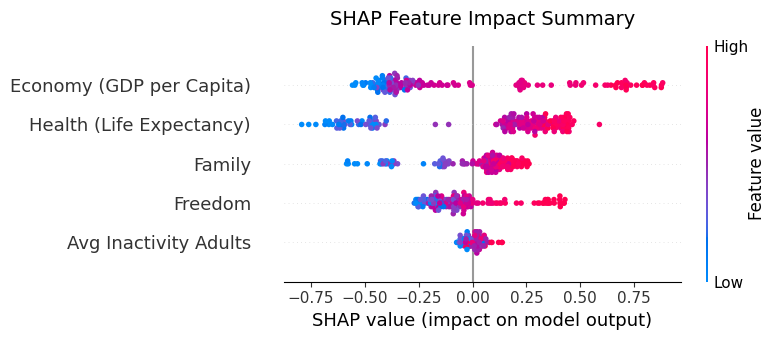

Happiest country: Finland
Least happy country: Afghanistan


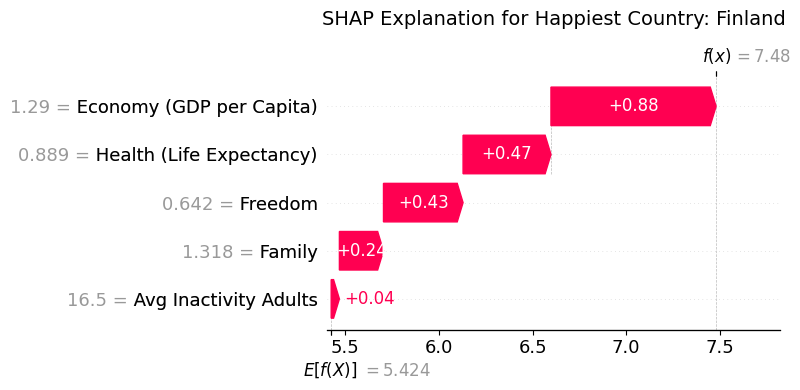

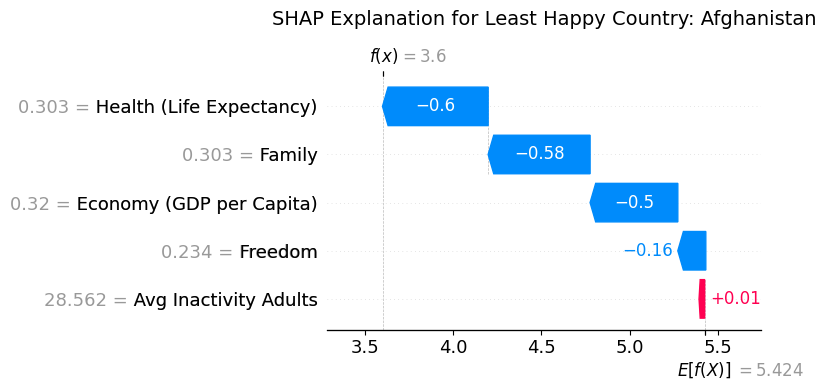

SHAP values successfully output to ./reports/country_shap_values.json


In [38]:
import shap
import json
import numpy as np

# Initialize TreeExplainer
explainer = shap.TreeExplainer(rf_best)

# Compute SHAP values for the whole dataset to plot all countries
X_shap = df_model[FEATURES]
shap_values = explainer(X_shap)
rf_shap_values = shap_values

mean_abs_shap = np.abs(rf_shap_values.values).mean(axis=0)
rf_shap_importance_percent = pd.DataFrame({
    'Feature': FEATURES,
    'Contribution (%)': mean_abs_shap / mean_abs_shap.sum() * 100
}).sort_values('Contribution (%)', ascending=False)
rf_shap_importance_percent['Contribution (%)'] = rf_shap_importance_percent['Contribution (%)'].round(1)

print('Random Forest SHAP contribution (% of mean absolute SHAP):')
print(rf_shap_importance_percent.to_string(index=False))

# 1. SHAP Summary Plot (global impact of features)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Feature Impact Summary', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'rf_shap_summary.png'), dpi=150)
plt.show()

# 2. Find index of notable countries
happiest_country = df_model.loc[df_model[TARGET].idxmax()]['Country']
least_happy_country = df_model.loc[df_model[TARGET].idxmin()]['Country']

print(f"Happiest country: {happiest_country}")
print(f"Least happy country: {least_happy_country}")

# Find indexes
happiest_idx = df_model[df_model['Country'] == happiest_country].index[0]
least_happy_idx = df_model[df_model['Country'] == least_happy_country].index[0]

# Waterfall plot for happiest country
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[happiest_idx], show=False)
plt.title(f"SHAP Explanation for Happiest Country: {happiest_country}", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "rf_shap_waterfall_happiest.png"), dpi=150)
plt.show()

# Waterfall plot for least happy country
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[least_happy_idx], show=False)
plt.title(f"SHAP Explanation for Least Happy Country: {least_happy_country}", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "rf_shap_waterfall_least_happy.png"), dpi=150)
plt.show()

# Output SHAP values to JSON for the simulator
country_shap = {}
for i, country in enumerate(df_model['Country']):
    country_shap[country] = {
        'Happiness_Score': float(df_model.loc[i, TARGET]),
        'GDP_per_Capita': float(df_model.loc[i, 'Economy (GDP per Capita)']),
        'Social_support': float(df_model.loc[i, 'Family']),
        'Life_Expectancy': float(df_model.loc[i, 'Health (Life Expectancy)']),
        'Freedom': float(df_model.loc[i, 'Freedom']),
        'Inactivity_Adults': float(df_model.loc[i, 'Avg Inactivity Adults']),
        'SHAP_GDP': float(shap_values.values[i, FEATURES.index('Economy (GDP per Capita)')]),
        'SHAP_Social': float(shap_values.values[i, FEATURES.index('Family')]),
        'SHAP_Health': float(shap_values.values[i, FEATURES.index('Health (Life Expectancy)')]),
        'SHAP_Freedom': float(shap_values.values[i, FEATURES.index('Freedom')]),
        'SHAP_Inactivity': float(shap_values.values[i, FEATURES.index('Avg Inactivity Adults')]),
        'SHAP_Base': float(np.atleast_1d(explainer.expected_value)[0])
    }

json_path = os.path.join(REPORTS_DIR, 'country_shap_values.json')
with open(json_path, 'w') as f:
    json.dump(country_shap, f, indent=2)
print(f"SHAP values successfully output to {json_path}")


## 6. Actual vs Predicted + Residual Plot

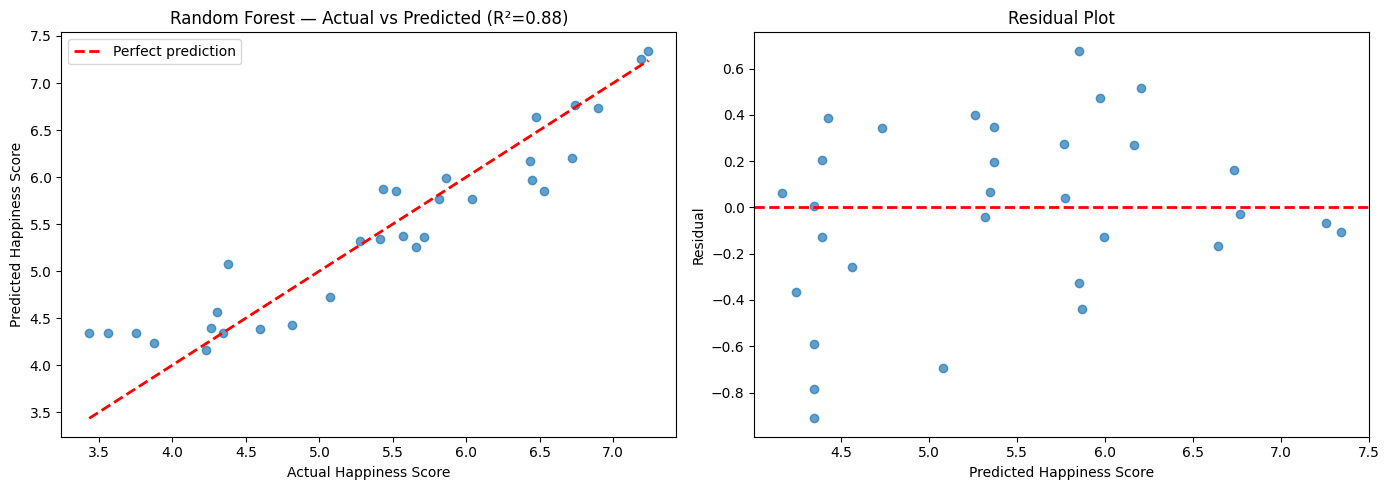

In [39]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Happiness Score')
axes[0].set_ylabel('Predicted Happiness Score')
axes[0].set_title(f'Random Forest — Actual vs Predicted (R²={r2_best:.2f})')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_best, residuals, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Happiness Score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'rf_actual_vs_predicted.png'), dpi=150)
plt.show()

## 7. Comparison: Baseline vs Tuned RF

In [40]:
summary = pd.DataFrame({
    'Model': ['RF Baseline', 'RF Tuned (GridSearchCV)'],
    'R²':   [round(r2_base, 4),  round(r2_best, 4)],
    'MAE':  [round(mae_base, 4), round(mae_best, 4)],
    'RMSE': [round(rmse_base, 4), round(rmse_best, 4)]
})
print(summary.to_string(index=False))

                  Model     R²    MAE   RMSE
            RF Baseline 0.8821 0.3026 0.3770
RF Tuned (GridSearchCV) 0.8763 0.3053 0.3861


## 8. Save Model

In [41]:
with open(os.path.join(MODELS_DIR, 'rf_best.pkl'), 'wb') as f:
    pickle.dump(rf_best, f)

print("Model saved to models/rf_best.pkl")

Model saved to models/rf_best.pkl



---
# Section 5: Gradient Boosting Regression
---

## Gradient Boosting Regression

Reported method: Gradient Boosting is the second ensemble regressor trained alongside Random Forest. This section trains and evaluates that model.


In [42]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

df = pd.read_csv(os.path.join(DATA_DIR, 'merged_clean.csv'))
print("Dataset shape:", df.shape)


Dataset shape: (152, 27)


In [43]:
TARGET = 'Happiness Score Avg'
FEATURES = [
    'Avg Inactivity Adults',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom'
]

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Baseline GB
gb_base = GradientBoostingRegressor(random_state=42)
gb_base.fit(X_train, y_train)
y_pred_base = gb_base.predict(X_test)

print("=== Baseline Gradient Boosting ===")
print(f"  R²   : {r2_score(y_test, y_pred_base):.4f}")

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\nBest parameters found:", grid_search.best_params_)
print(f"Best CV R²:           {grid_search.best_score_:.4f}")

# Best estimator evaluation
gb_best = grid_search.best_estimator_
y_pred_best = gb_best.predict(X_test)

r2_best   = r2_score(y_test, y_pred_best)
mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
gb_r2_best = r2_best
gb_mae_best = mae_best
gb_rmse_best = rmse_best

# Shuffled 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
gb_cv_scores = cross_val_score(gb_best, X, y, cv=kf, scoring='r2')

print("\n=== Tuned Gradient Boosting ===")
print(f"  R²   : {r2_best:.4f}")
print(f"  MAE  : {mae_best:.4f}")
print(f"  RMSE : {rmse_best:.4f}")
print(f"  CV R² (5-fold, Shuffled): {gb_cv_scores} → mean {gb_cv_scores.mean():.4f}")


=== Baseline Gradient Boosting ===
  R²   : 0.8641

Best parameters found: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV R²:           0.7813

=== Tuned Gradient Boosting ===
  R²   : 0.8750
  MAE  : 0.3031
  RMSE : 0.3881
  CV R² (5-fold, Shuffled): [0.8749934  0.7787474  0.79332396 0.83182143 0.81300929] → mean 0.8184


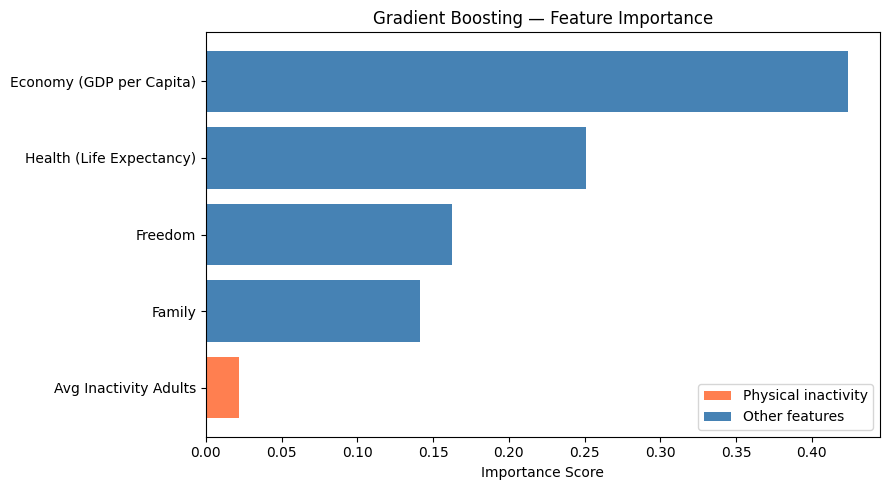

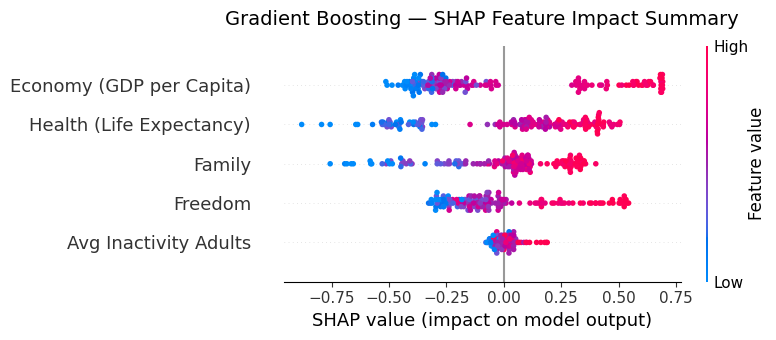

Model saved to models/gb_best.pkl


In [44]:
# Plot Feature Importance
importances = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': gb_best.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['coral' if 'Inactivity' in f else 'steelblue' for f in importances['Feature']]
plt.barh(importances['Feature'], importances['Importance'], color=colors)
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', label='Physical inactivity'),
    Patch(facecolor='steelblue', label='Other features')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'gb_feature_importance.png'), dpi=150)
plt.show()

# SHAP Analysis
explainer = shap.TreeExplainer(gb_best)
shap_values = explainer(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.title('Gradient Boosting — SHAP Feature Impact Summary', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'gb_shap_summary.png'), dpi=150)
plt.show()

# Save the model
with open(os.path.join(MODELS_DIR, 'gb_best.pkl'), 'wb') as f:
    pickle.dump(gb_best, f)
print("Model saved to models/gb_best.pkl")


In [45]:
# Model Comparison Summary
# Model comparison table generated from the current run variables.
comparison_df = pd.DataFrame({
    'Model': ['Multiple OLS Regression', 'Tuned Random Forest', 'Tuned Gradient Boosting'],
    'R² (Test)': [round(r2_multi, 4), round(rf_r2_best, 4), round(gb_r2_best, 4)],
    'MAE': [round(mae_multi, 4), round(rf_mae_best, 4), round(gb_mae_best, 4)],
    'RMSE': [round(rmse_multi, 4), round(rf_rmse_best, 4), round(gb_rmse_best, 4)]
})
print("=== Model Comparison Summary ===")
print(comparison_df.to_string(index=False))


=== Model Comparison Summary ===
                  Model  R² (Test)    MAE   RMSE
Multiple OLS Regression     0.8292 0.3431 0.4537
    Tuned Random Forest     0.8763 0.3053 0.3861
Tuned Gradient Boosting     0.8750 0.3031 0.3881



---
# Section 6: K-Means Clustering
---

# K-Means Clustering: Country Profiles by Development and Inactivity

K-Means is used to group countries into structural profiles based on GDP per capita, healthy life expectancy, social support, freedom, and adult physical inactivity. The resulting clusters are interpreted as high-income sedentary, low-income active, and middle-income high-sedentary country profiles.


In [46]:
# Ensure Colab path variables and datasets are ready (in case setup cell was skipped)
import os
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = './data' if IN_COLAB else '../data'
REPORTS_DIR = './reports' if IN_COLAB else '../reports'
MODELS_DIR = './models' if IN_COLAB else '../models'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Auto-upload check
_req_files = ['world_happiness.csv', 'world_happiness_allyears.csv', 'who_physical_activity.csv']
for _f in _req_files:
    if os.path.exists(_f) and not os.path.exists(os.path.join(DATA_DIR, _f)):
        shutil.move(_f, os.path.join(DATA_DIR, _f))
_missing = [_f for _f in _req_files if not os.path.exists(os.path.join(DATA_DIR, _f))]
if _missing and IN_COLAB:
    print(f"Missing datasets in Colab: {_missing}")
    print("Please upload the required files using the upload window below:")
    _uploaded = files.upload()
    for _name in _uploaded.keys():
        if _name in _req_files:
            shutil.move(_name, os.path.join(DATA_DIR, _name))
            print(f"Moved uploaded file: {_name} -> {os.path.join(DATA_DIR, _name)}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, 'merged_clean.csv'))
print("Dataset shape:", df.shape)

Dataset shape: (152, 27)


## 1. Feature Selection & Scaling

K-Means is distance-based so features **must** be standardised (mean=0, std=1) before clustering.

In [47]:
CLUSTER_FEATURES = [
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
    'Family',
    'Freedom',
    'Avg Inactivity Adults'
]
PROFILE_FEATURES = ['Happiness Score'] + CLUSTER_FEATURES

df_cluster = df[PROFILE_FEATURES + ['Country', 'Region']].dropna().copy()
X = df_cluster[CLUSTER_FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Countries used for clustering: {len(df_cluster)}")

Countries used for clustering: 152


## 2. Choosing k: Elbow Method and Silhouette Score

Final report: Fig. 22 (`reports/kmeans_elbow_silhouette.png`).


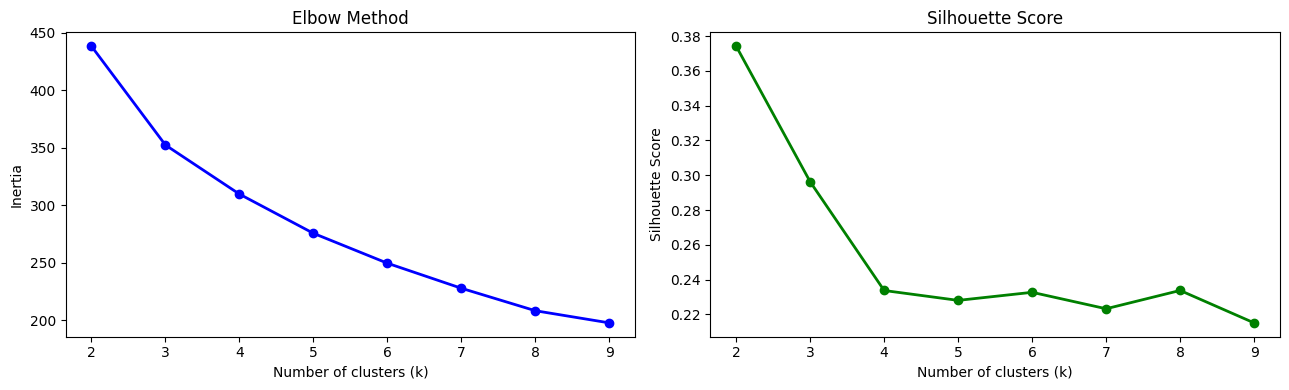

Highest silhouette score at k=2 (score=0.374)


In [48]:
inertias = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'kmeans_elbow_silhouette.png'), dpi=150)
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Highest silhouette score at k={best_k} (score={max(silhouettes):.3f})")

## 3. Fit Final K-Means Model

In [49]:
# You can override k here if you prefer a different value based on the elbow/silhouette plots
K = 3  # Overridden to 3 clusters for richer profiling

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Fitted K-Means with k={K}")
print("Countries per cluster:")
print(df_cluster['Cluster'].value_counts().sort_index().to_string())

Fitted K-Means with k=3
Countries per cluster:
Cluster
0    67
1    48
2    37


## 4. Cluster Profiles

Final report: Table III.


=== Cluster Profiles ===
         Happiness Score  Economy (GDP per Capita)  Health (Life Expectancy)  Family  Freedom  Avg Inactivity Adults
Cluster                                                                                                             
0                   6.35                      1.12                      0.79    1.20     0.55                  32.08
1                   4.26                      0.37                      0.34    0.75     0.38                  20.52
2                   5.05                      0.95                      0.70    0.94     0.27                  32.62


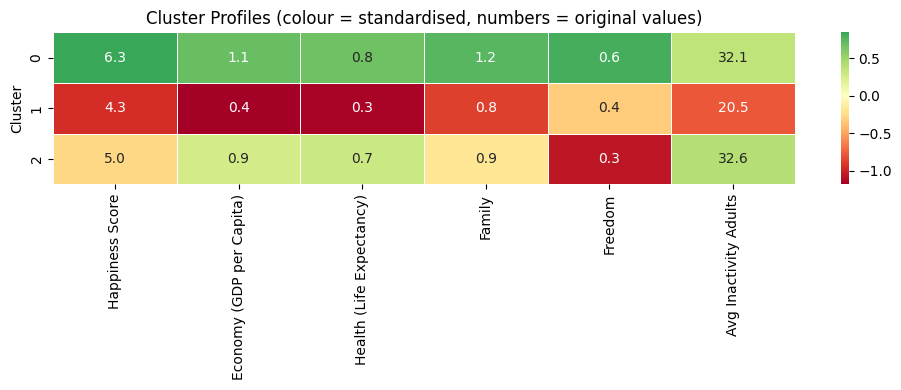

In [50]:
cluster_profiles = df_cluster.groupby('Cluster')[PROFILE_FEATURES].mean().round(2)
print("=== Cluster Profiles ===")
print(cluster_profiles.to_string())

# Heatmap of cluster profiles (standardized using a profile-specific scaler for visualization)
profile_scaler = StandardScaler()
profile_scaler.fit(df_cluster[PROFILE_FEATURES])
profiles_scaled = pd.DataFrame(
    profile_scaler.transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=PROFILE_FEATURES
)

plt.figure(figsize=(10, 4))
sns.heatmap(profiles_scaled, annot=cluster_profiles.values, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Cluster Profiles (colour = standardised, numbers = original values)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'kmeans_cluster_profiles.png'), dpi=150)
plt.show()

## 5. Cluster Scatter Plot: Inactivity vs Happiness


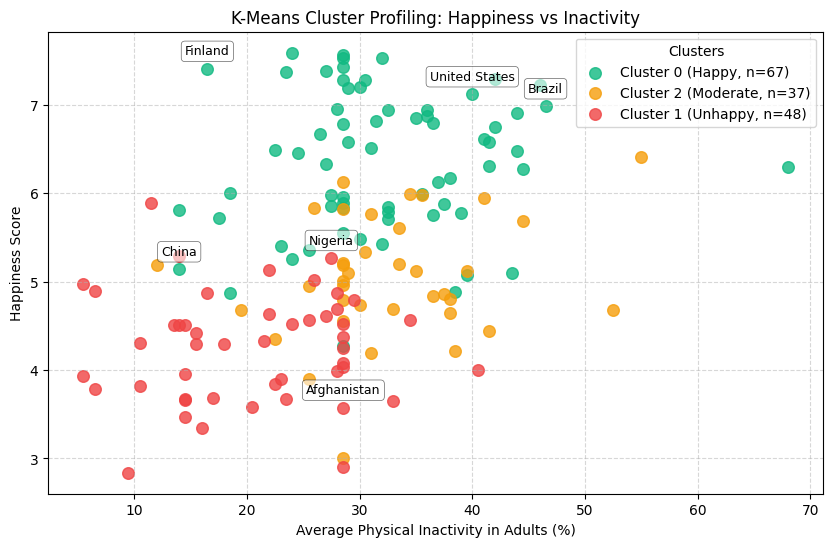

In [51]:
cluster_colors = {0: '#10b981', 1: '#ef4444', 2: '#f59e0b'}
cluster_names = {0: 'Happy', 1: 'Unhappy', 2: 'Moderate'}

plt.figure(figsize=(10, 6))
for cluster_id in [0, 2, 1]:  # Ordered Happy, Moderate, Unhappy
    subset = df_cluster[df_cluster['Cluster'] == cluster_id]
    plt.scatter(
        subset['Avg Inactivity Adults'], subset['Happiness Score'],
        label=f'Cluster {cluster_id} ({cluster_names[cluster_id]}, n={len(subset)})',
        color=cluster_colors[cluster_id], alpha=0.8, s=70
    )

# Annotate a few interesting countries
notable = ['Finland', 'Afghanistan', 'United States', 'China', 'Brazil', 'Nigeria']
for _, row in df_cluster[df_cluster['Country'].isin(notable)].iterrows():
    plt.annotate(
        row['Country'],
        (row['Avg Inactivity Adults'], row['Happiness Score']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.6, lw=0.5)
    )

plt.xlabel('Average Physical Inactivity in Adults (%)')
plt.ylabel('Happiness Score')
plt.title('K-Means Cluster Profiling: Happiness vs Inactivity')
plt.legend(title='Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(REPORTS_DIR, 'kmeans_scatter.png'), dpi=150)
plt.show()

## 6. PCA Projection and Explained Variance

Final report: Fig. 23 (`reports/kmeans_pca.png`).


PCA variance explained:
  PC1: 57.9% (cumulative 57.9%)
  PC2: 19.6% (cumulative 77.5%)
  PC3: 10.5% (cumulative 88.0%)
  PC4: 9.1% (cumulative 97.1%)
  PC5: 2.9% (cumulative 100.0%)
PC1 + PC2: 77.5%
PC1 + PC2 + PC3: 88.0%


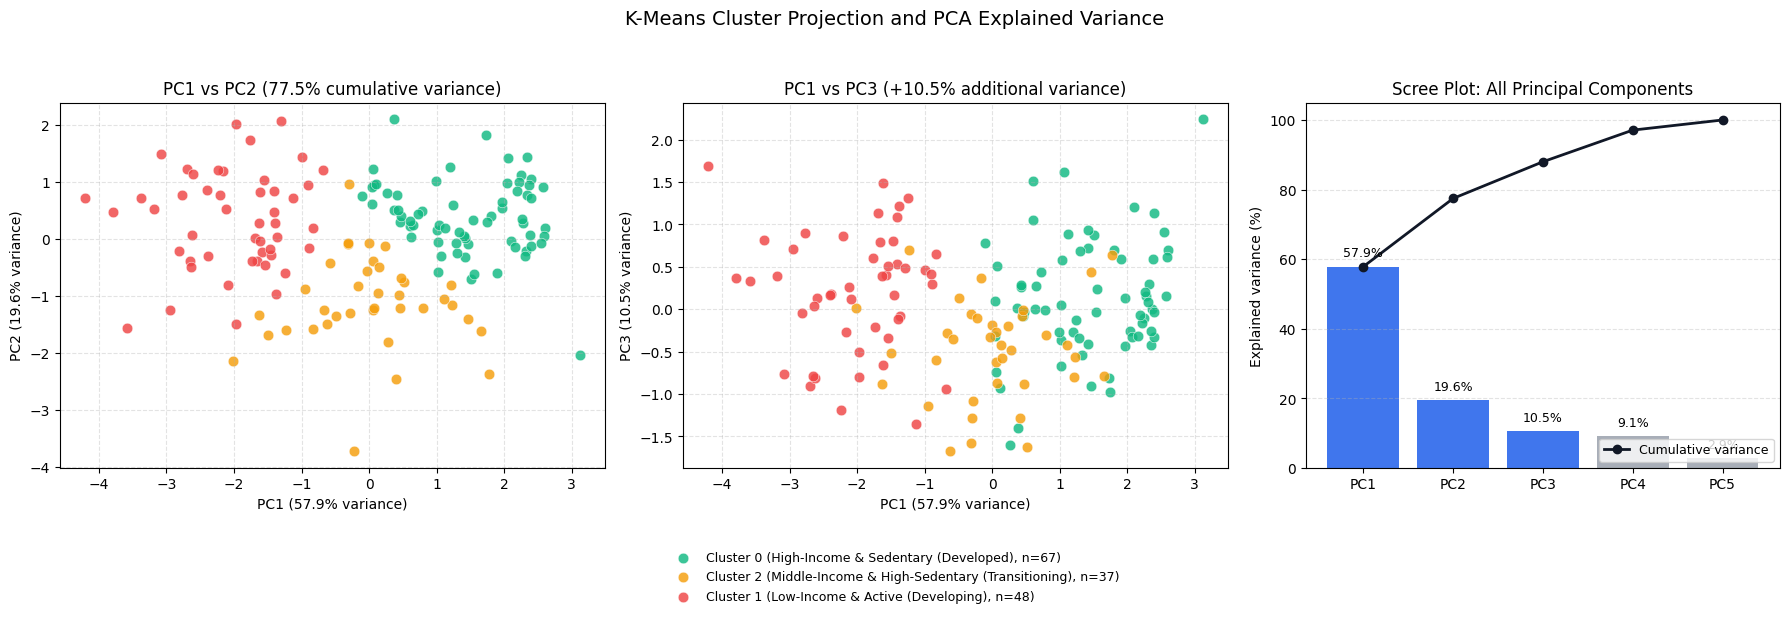

In [52]:
# Fit PCA across all five clustering features so that the scree plot accounts for 100% variance
pca = PCA(n_components=len(CLUSTER_FEATURES), random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("PCA variance explained:")
for i, value in enumerate(explained, start=1):
    print(f"  PC{i}: {value:.1%} (cumulative {cumulative[i-1]:.1%})")
print(f"PC1 + PC2: {cumulative[1]:.1%}")
print(f"PC1 + PC2 + PC3: {cumulative[2]:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1.15, 1.15, 1]})

cluster_colors = {0: '#10b981', 1: '#ef4444', 2: '#f59e0b'}
cluster_names = {
    0: 'High-Income & Sedentary (Developed)',
    1: 'Low-Income & Active (Developing)',
    2: 'Middle-Income & High-Sedentary (Transitioning)'
}
plot_order = [0, 2, 1]

# PC1 vs PC2: the main two-dimensional projection
for cluster_id in plot_order:
    mask = df_cluster['Cluster'] == cluster_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"Cluster {cluster_id} ({cluster_names[cluster_id]}, n={mask.sum()})",
        color=cluster_colors[cluster_id], alpha=0.82, s=58, edgecolors='white', linewidths=0.4
    )
axes[0].set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
axes[0].set_title(f"PC1 vs PC2 ({cumulative[1]:.1%} cumulative variance)")
axes[0].grid(True, linestyle='--', alpha=0.35)

# PC1 vs PC3: additional structure beyond the first two components
for cluster_id in plot_order:
    mask = df_cluster['Cluster'] == cluster_id
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 2],
        label=f"Cluster {cluster_id} ({cluster_names[cluster_id]}, n={mask.sum()})",
        color=cluster_colors[cluster_id], alpha=0.82, s=58, edgecolors='white', linewidths=0.4
    )
axes[1].set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
axes[1].set_ylabel(f"PC3 ({explained[2]:.1%} variance)")
axes[1].set_title(f"PC1 vs PC3 (+{explained[2]:.1%} additional variance)")
axes[1].grid(True, linestyle='--', alpha=0.35)

# Scree plot for all five components
component_labels = [f"PC{i}" for i in range(1, len(explained) + 1)]
bar_colors = ['#2563eb' if i < 3 else '#9ca3af' for i in range(len(explained))]
axes[2].bar(component_labels, explained * 100, color=bar_colors, alpha=0.88)
axes[2].plot(component_labels, cumulative * 100, color='#111827', marker='o', linewidth=2, label='Cumulative variance')
axes[2].set_ylim(0, 105)
axes[2].set_ylabel('Explained variance (%)')
axes[2].set_title('Scree Plot: All Principal Components')
axes[2].grid(True, axis='y', linestyle='--', alpha=0.35)
for i, value in enumerate(explained * 100):
    axes[2].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=9)
axes[2].legend(loc='lower right', fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=1, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('K-Means Cluster Projection and PCA Explained Variance', fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.savefig(os.path.join(REPORTS_DIR, 'kmeans_pca.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Countries per Cluster

In [53]:
for cluster_id in range(K):
    subset = df_cluster[df_cluster['Cluster'] == cluster_id]
    countries = ', '.join(sorted(subset['Country'].tolist()))
    happiness_mean = subset['Happiness Score'].mean()
    inactivity_mean = subset['Avg Inactivity Adults'].mean()
    print(f"\n--- Cluster {cluster_id} (n={len(subset)}) ---")
    print(f"  Avg Happiness : {happiness_mean:.2f}")
    print(f"  Avg Inactivity: {inactivity_mean:.1f}%")
    print(f"  Countries: {countries}")


--- Cluster 0 (n=67) ---
  Avg Happiness : 6.35
  Avg Inactivity: 32.1%
  Countries: Argentina, Australia, Austria, Bahrain, Belarus, Belgium, Bhutan, Bolivia, Brazil, Canada, Chile, China, Colombia, Costa Rica, Czech Republic, Denmark, Dominican Republic, Ecuador, Estonia, Finland, France, Germany, Guatemala, Iceland, Indonesia, Ireland, Israel, Jamaica, Japan, Kazakhstan, Kuwait, Libya, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Mongolia, Netherlands, New Zealand, Nicaragua, Norway, Oman, Panama, Paraguay, Philippines, Poland, Portugal, Qatar, Russia, Singapore, Slovenia, Spain, Sri Lanka, Suriname, Sweden, Switzerland, Thailand, Trinidad and Tobago, Turkmenistan, United Arab Emirates, United Kingdom, United States, Uruguay, Uzbekistan, Venezuela, Vietnam

--- Cluster 1 (n=48) ---
  Avg Happiness : 4.26
  Avg Inactivity: 20.5%
  Countries: Afghanistan, Angola, Bangladesh, Benin, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo 

## 8. Save Model & Labelled Dataset

In [54]:
with open(os.path.join(MODELS_DIR, 'kmeans.pkl'), 'wb') as f:
    pickle.dump(kmeans, f)

with open(os.path.join(MODELS_DIR, 'kmeans_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save dataset with cluster labels
df_with_clusters = df.merge(
    df_cluster[['Country', 'Cluster']], on='Country', how='left'
)
df_with_clusters.to_csv(os.path.join(DATA_DIR, 'merged_with_clusters.csv'), index=False)

print("Saved kmeans.pkl, kmeans_scaler.pkl, and merged_with_clusters.csv")

Saved kmeans.pkl, kmeans_scaler.pkl, and merged_with_clusters.csv


## Reported Metrics Check

This cell prints selected numerical outputs after the notebook has been run from top to bottom.


In [55]:
print('=== Reported Metrics Check ===')
print(f"Dataset: {len(df)} countries, {df.shape[1]} features")
print()

print('OLS regression:')
print(f"  Simple LR test R²: {r2_simple:.4f}")
print(f"  Simple LR 5-fold CV R² mean: {cv_simple.mean():.3f}")
print(f"  Multiple OLS test R²: {r2_multi:.4f}")
print(f"  Multiple OLS adjusted R²: {adj_r2_multi:.4f}")
print(f"  Multiple OLS 5-fold CV R² mean: {cv_multi.mean():.3f}")
print(f"  Inactivity coefficient after controls: {lr_multi.coef_[MULTI_FEATURES.index('Avg Inactivity Adults')]:.4f}")
print()

print('Random Forest:')
print(f"  Tuned RF test R²: {rf_r2_best:.4f}")
print(f"  Tuned RF 5-fold CV R² mean: {rf_cv_scores.mean():.3f}")
print()

print('Random Forest SHAP contribution (% of mean absolute SHAP):')
print(rf_shap_importance_percent.to_string(index=False))
print()

print('K-Means cluster profile means:')
print(cluster_profiles[['Happiness Score', 'Avg Inactivity Adults', 'Economy (GDP per Capita)', 'Health (Life Expectancy)', 'Family']].to_string())
print()

print('PCA explained variance:')
for i, value in enumerate(explained, start=1):
    print(f"  PC{i}: {value:.1%} (cumulative {cumulative[i-1]:.1%})")


=== Reported Metrics Check ===
Dataset: 152 countries, 27 features

OLS regression:
  Simple LR test R²: 0.3093
  Simple LR 5-fold CV R² mean: 0.133
  Multiple OLS test R²: 0.8292
  Multiple OLS adjusted R²: 0.7950
  Multiple OLS 5-fold CV R² mean: 0.807
  Inactivity coefficient after controls: 0.0017

Random Forest:
  Tuned RF test R²: 0.8763
  Tuned RF 5-fold CV R² mean: 0.823

Random Forest SHAP contribution (% of mean absolute SHAP):
                 Feature  Contribution (%)
Economy (GDP per Capita)              36.4
Health (Life Expectancy)              32.4
                  Family              14.9
                 Freedom              13.6
   Avg Inactivity Adults               2.8

K-Means cluster profile means:
         Happiness Score  Avg Inactivity Adults  Economy (GDP per Capita)  Health (Life Expectancy)  Family
Cluster                                                                                                    
0                   6.35                  32.08     